In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# 解決 matplotlib 中文顯示問題
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macOS 使用 Arial Unicode MS
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

data = pd.read_csv('data_choice_complete.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45211 non-null  float64
 1   job        45211 non-null  float64
 2   marital    45211 non-null  float64
 3   education  45211 non-null  float64
 4   balance    45211 non-null  float64
 5   housing    45211 non-null  float64
 6   loan       45211 non-null  float64
 7   month      45211 non-null  float64
 8   duration   45211 non-null  float64
 9   campaign   45211 non-null  float64
 10  y          45211 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 3.8 MB


In [45]:
from sklearn.model_selection import train_test_split

X=data.drop('y', axis=1)
y=data['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((36168, 10), (9043, 10), (36168,), (9043,))

# Logistic Regression 模型訓練

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# 使用 GridSearchCV 調整 C 參數
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(
    LogisticRegression(penalty='l2', max_iter=1000),
    param_grid,
    cv=10,  # 用 CV 評估每個 C 值的表現
    scoring='accuracy'
)
grid_search.fit(X_train, y_train)
print(f"最佳 C 值: {grid_search.best_params_['C']}")


# 建立 Logistic Regression 模型
log_reg = LogisticRegression(penalty='l2', C=grid_search.best_params_['C'], max_iter=1000)

# 訓練模型
log_reg.fit(X_train, y_train)

# 預測
y_pred_log = log_reg.predict(X_test)

# 計算準確率
log_acc = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression 準確率: {log_acc:.4f} ({log_acc*100:.2f}%)")
print("\n分類報告:")
print(classification_report(y_test, y_pred_log))

最佳 C 值: 100
Logistic Regression 準確率: 0.8891 (88.91%)

分類報告:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      8009
           1       0.64      0.07      0.12      1034

    accuracy                           0.89      9043
   macro avg       0.77      0.53      0.53      9043
weighted avg       0.86      0.89      0.85      9043



## 混淆距陣

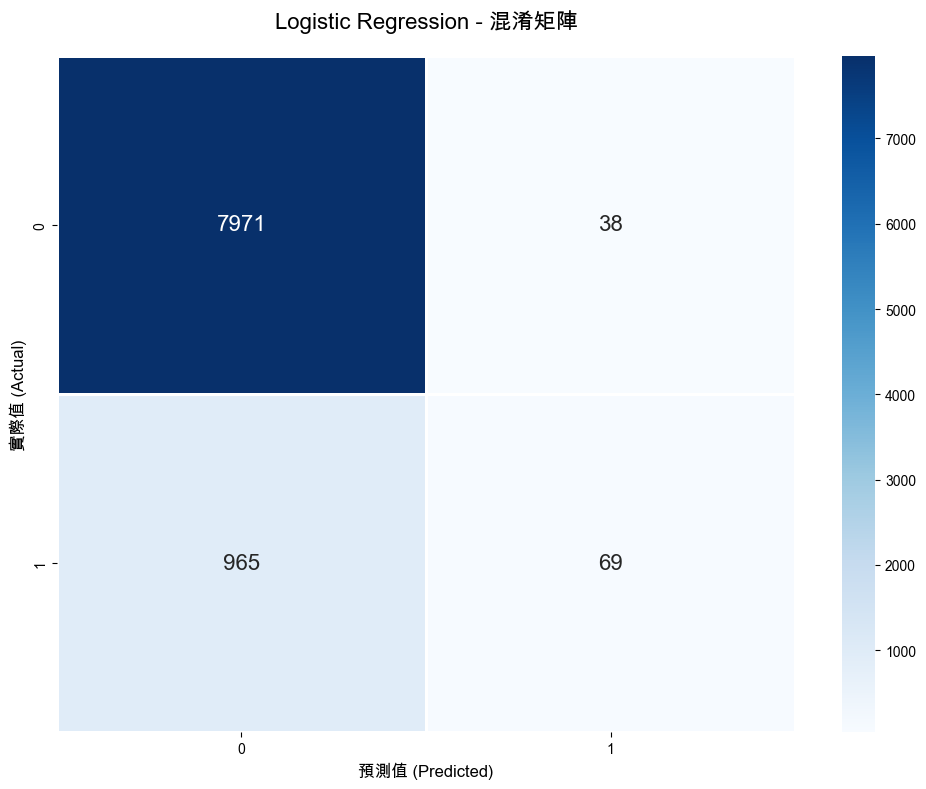

混淆矩陣分析:

True Negative (TN):   7971 - 正確預測為「未訂閱」
False Positive (FP):    38 - 錯誤預測為「訂閱」(Type I Error)
False Negative (FN):   965 - 錯誤預測為「未訂閱」(Type II Error)
True Positive (TP):     69 - 正確預測為「訂閱」

從混淆矩陣計算的評估指標:
準確率 (Accuracy):    0.8891 (88.91%)
  → (TP + TN) / 總數 = (69 + 7971) / 9043

精確率 (Precision):   0.6449 (64.49%)
  → TP / (TP + FP) = 69 / (69 + 38)
  → 預測為「訂閱」中，真正訂閱的比例

召回率 (Recall):      0.0667 (6.67%)
  → TP / (TP + FN) = 69 / (69 + 965)
  → 實際「訂閱」中，被正確找出的比例

特異度 (Specificity): 0.9953 (99.53%)
  → TN / (TN + FP) = 7971 / (7971 + 38)
  → 實際「未訂閱」中，被正確識別的比例

F1 分數 (F1-Score):   0.1209
  → 2 × (Precision × Recall) / (Precision + Recall)

業務意義解讀:
• Type I Error (FP=38):  誤判為會訂閱 → 浪費行銷資源
• Type II Error (FN=965): 漏掉潛在客戶 → 失去商機
• 如果重視「不錯過客戶」→ 提高 Recall (降低 FN)
• 如果重視「精準行銷」→ 提高 Precision (降低 FP)


In [47]:
# 視覺化 Logistic Regression 的混淆矩陣
plt.figure(figsize=(10, 8))
cm_log = confusion_matrix(y_test, y_pred_log)

# 繪製混淆矩陣熱力圖
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=True, 
            annot_kws={'size': 16}, linewidths=2, linecolor='white')
plt.title('Logistic Regression - 混淆矩陣', fontsize=16, pad=20)
plt.ylabel('實際值 (Actual)', fontsize=12)
plt.xlabel('預測值 (Predicted)', fontsize=12)
plt.tight_layout()
plt.show()

# 詳細分析混淆矩陣
print("=" * 60)
print("混淆矩陣分析:")
print("=" * 60)

# 假設是二元分類 (0: 未訂閱, 1: 訂閱)
TN = cm_log[0, 0]  # True Negative: 正確預測為 0
FP = cm_log[0, 1]  # False Positive: 錯誤預測為 1 (Type I Error)
FN = cm_log[1, 0]  # False Negative: 錯誤預測為 0 (Type II Error)
TP = cm_log[1, 1]  # True Positive: 正確預測為 1

print(f"\nTrue Negative (TN):  {TN:5d} - 正確預測為「未訂閱」")
print(f"False Positive (FP): {FP:5d} - 錯誤預測為「訂閱」(Type I Error)")
print(f"False Negative (FN): {FN:5d} - 錯誤預測為「未訂閱」(Type II Error)")
print(f"True Positive (TP):  {TP:5d} - 正確預測為「訂閱」")

# 計算各項指標
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\n" + "=" * 60)
print("從混淆矩陣計算的評估指標:")
print("=" * 60)
print(f"準確率 (Accuracy):    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  → (TP + TN) / 總數 = ({TP} + {TN}) / {TP+TN+FP+FN}")
print(f"\n精確率 (Precision):   {precision:.4f} ({precision*100:.2f}%)")
print(f"  → TP / (TP + FP) = {TP} / ({TP} + {FP})")
print(f"  → 預測為「訂閱」中，真正訂閱的比例")
print(f"\n召回率 (Recall):      {recall:.4f} ({recall*100:.2f}%)")
print(f"  → TP / (TP + FN) = {TP} / ({TP} + {FN})")
print(f"  → 實際「訂閱」中，被正確找出的比例")
print(f"\n特異度 (Specificity): {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  → TN / (TN + FP) = {TN} / ({TN} + {FP})")
print(f"  → 實際「未訂閱」中，被正確識別的比例")
print(f"\nF1 分數 (F1-Score):   {f1:.4f}")
print(f"  → 2 × (Precision × Recall) / (Precision + Recall)")

print("\n" + "=" * 60)
print("業務意義解讀:")
print("=" * 60)
print(f"• Type I Error (FP={FP}):  誤判為會訂閱 → 浪費行銷資源")
print(f"• Type II Error (FN={FN}): 漏掉潛在客戶 → 失去商機")
print(f"• 如果重視「不錯過客戶」→ 提高 Recall (降低 FN)")
print(f"• 如果重視「精準行銷」→ 提高 Precision (降低 FP)")

# ROC Curve & AUC

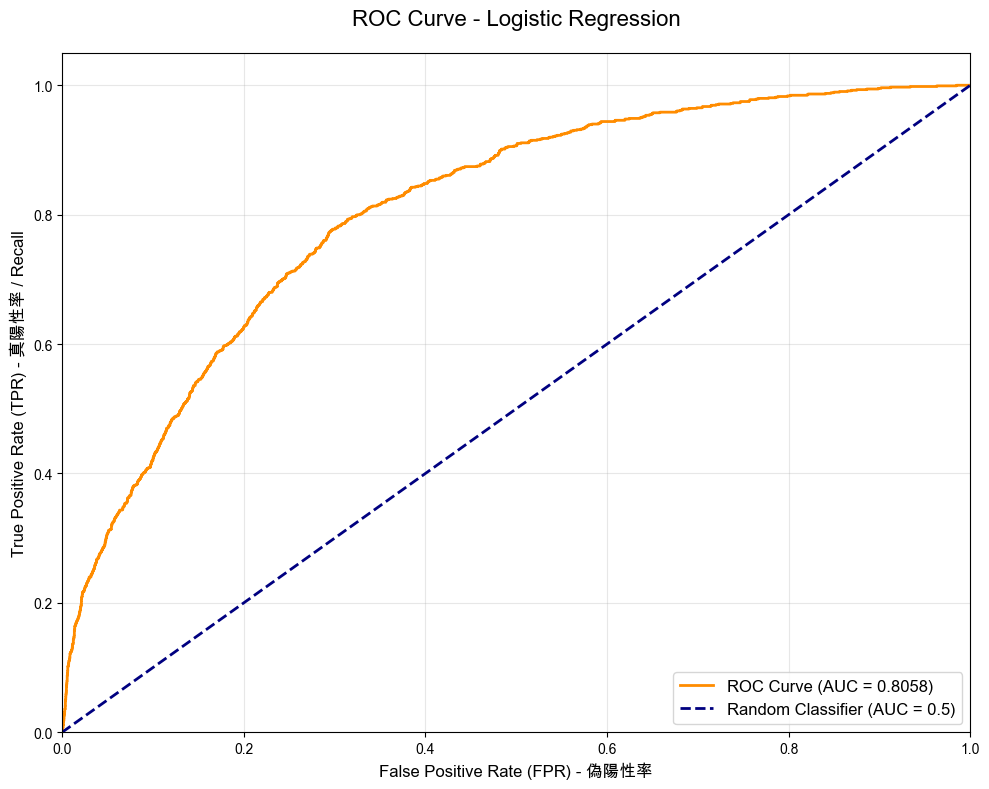

ROC Curve & AUC 分析結果:

AUC (Area Under Curve) 分數: 0.8058
  → AUC 範圍: 0.0 ~ 1.0
  → AUC = 1.0: 完美分類器
  → AUC = 0.5: 隨機猜測（無預測能力）
  → AUC < 0.5: 比隨機猜測還差

ROC Curve 解讀:
• X 軸 (FPR): False Positive Rate = FP / (FP + TN)
  → 實際為「未訂閱」中，被誤判為「訂閱」的比例

• Y 軸 (TPR): True Positive Rate = TP / (TP + FN) = Recall
  → 實際為「訂閱」中，被正確找出的比例

• 曲線越靠近左上角越好（高 TPR、低 FPR）
• 藍色虛線：隨機分類器的基準線
• 橘色實線：我們的模型表現

AUC 評估標準:
✓ AUC = 0.8058 → 良好 (Good)

業務應用:
• 可調整分類閾值（threshold）來平衡 FPR 與 TPR
• 降低閾值 → 提高 TPR (找到更多訂閱客戶) 但 FPR 也上升
• 提高閾值 → 降低 FPR (減少誤判) 但 TPR 也下降
• 預設閾值 = 0.5，可根據業務需求調整

不同閾值下的 TPR 與 FPR (前 5 個閾值):
      閾值 |    TPR (Recall) |        FPR
----------------------------------------
     inf |          0.0000 |     0.0000
  0.6322 |          0.0000 |     0.0001
  0.6142 |          0.0019 |     0.0001
  0.5896 |          0.0019 |     0.0005
  0.5883 |          0.0029 |     0.0005


In [48]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# 取得預測機率（正類的機率）
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# 計算 ROC 曲線的數據點
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 計算 AUC 分數
roc_auc = auc(fpr, tpr)
# 或使用: roc_auc = roc_auc_score(y_test, y_pred_proba)

# 繪製 ROC 曲線
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR) - 偽陽性率', fontsize=12)
plt.ylabel('True Positive Rate (TPR) - 真陽性率 / Recall', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=16, pad=20)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 詳細說明
print("=" * 70)
print("ROC Curve & AUC 分析結果:")
print("=" * 70)
print(f"\nAUC (Area Under Curve) 分數: {roc_auc:.4f}")
print(f"  → AUC 範圍: 0.0 ~ 1.0")
print(f"  → AUC = 1.0: 完美分類器")
print(f"  → AUC = 0.5: 隨機猜測（無預測能力）")
print(f"  → AUC < 0.5: 比隨機猜測還差")

print("\n" + "=" * 70)
print("ROC Curve 解讀:")
print("=" * 70)
print("• X 軸 (FPR): False Positive Rate = FP / (FP + TN)")
print("  → 實際為「未訂閱」中，被誤判為「訂閱」的比例")
print("\n• Y 軸 (TPR): True Positive Rate = TP / (TP + FN) = Recall")
print("  → 實際為「訂閱」中，被正確找出的比例")
print("\n• 曲線越靠近左上角越好（高 TPR、低 FPR）")
print("• 藍色虛線：隨機分類器的基準線")
print("• 橘色實線：我們的模型表現")

print("\n" + "=" * 70)
print("AUC 評估標準:")
print("=" * 70)
if roc_auc >= 0.9:
    print(f"✓ AUC = {roc_auc:.4f} → 優秀 (Excellent)")
elif roc_auc >= 0.8:
    print(f"✓ AUC = {roc_auc:.4f} → 良好 (Good)")
elif roc_auc >= 0.7:
    print(f"○ AUC = {roc_auc:.4f} → 尚可 (Fair)")
elif roc_auc >= 0.6:
    print(f"△ AUC = {roc_auc:.4f} → 不佳 (Poor)")
else:
    print(f"✗ AUC = {roc_auc:.4f} → 失敗 (Fail)")

print("\n" + "=" * 70)
print("業務應用:")
print("=" * 70)
print("• 可調整分類閾值（threshold）來平衡 FPR 與 TPR")
print("• 降低閾值 → 提高 TPR (找到更多訂閱客戶) 但 FPR 也上升")
print("• 提高閾值 → 降低 FPR (減少誤判) 但 TPR 也下降")
print(f"• 預設閾值 = 0.5，可根據業務需求調整")

# 顯示幾個關鍵閾值點
print("\n" + "=" * 70)
print("不同閾值下的 TPR 與 FPR (前 5 個閾值):")
print("=" * 70)
print(f"{'閾值':>8} | {'TPR (Recall)':>15} | {'FPR':>10}")
print("-" * 40)
for i in range(min(5, len(thresholds))):
    print(f"{thresholds[i]:>8.4f} | {tpr[i]:>15.4f} | {fpr[i]:>10.4f}")

## AUC 就是 ROC Curve 下方的面積！

**視覺化理解：**
- ROC Curve（橘色曲線）與 X 軸、Y 軸所圍成的面積 = AUC
- 面積範圍：0.0 ~ 1.0

**為什麼 AUC 是好指標？**
1. **單一數值**：把整條 ROC 曲線濃縮成一個分數，方便比較模型
2. **與閾值無關**：評估模型在「所有可能閾值」下的整體表現
3. **類別不平衡友善**：即使正負樣本比例懸殊，AUC 仍能反映真實能力

**幾何意義：**
- AUC = 1.0 → 完美分類器，曲線緊貼左上角（最大面積）
- AUC = 0.5 → 隨機猜測，曲線是對角線（面積剛好一半）
- AUC < 0.5 → 比隨機還差（預測方向相反）

**機率意義：**
AUC 也代表「隨機挑一個正樣本和一個負樣本，模型給正樣本更高分數的機率」  
→ AUC = 0.9 表示有 90% 的機率，模型能正確排序正負樣本